### Task: Using this sample dataset, create or optimize data preprocessing pipeline using opencv and pytorch and include image mask technique in the pipeline and save the output.

In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
data_path =  "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE"

In [17]:

import os

print("Files in data folder:")
for f in os.listdir(data_path)[:10]:  # Show first 10
    print(f"  {f}")

image_dir = os.path.join(data_path, "images")
mask_dir = os.path.join(data_path, "annotations")  # Or "masks"

# If those don't exist, use the root folder
if not os.path.exists(image_dir):
    image_dir = data_path
if not os.path.exists(mask_dir):
    mask_dir = data_path

print(f"\nUsing image dir: {image_dir}")
print(f"Using mask dir: {mask_dir}")

Files in data folder:
  image_0.jpg
  image_1.jpg
  image_2.jpg
  image_3.jpg
  image_4.jpg

Using image dir: /content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE
Using mask dir: /content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE


In [ ]:

import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

#  mask technique
def apply_mask_technique(image, mask=None):

    # If mask exists, use it. If not, create one using a simple technique.

    if mask is not None and mask.max() > 0:  # If mask exists and isn't empty
        return mask

    #  mask based on image edges
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    # Make edges thicker so mask is visible
    kernel = np.ones((3, 3), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    return edges

# transform function
def simple_transform(image, mask, size=(256, 256)):
    # Resize and normalize both image and mask
    # Resize
    image = cv2.resize(image, size)
    mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

    # Apply mask technique if mask is weak
    mask = apply_mask_technique(image, mask)

    # Make mask binary (0 or 255)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Normalize image to 0-1
    image = image.astype(np.float32) / 255.0

    return image, mask

In [19]:
# Dataset class
class SimpleCOCODataset(Dataset):
    def __init__(self, image_dir, mask_dir=None, transform_func=None, img_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform_func = transform_func
        self.img_size = img_size

        # Get image files
        self.images = [f for f in os.listdir(image_dir)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Try to find matching mask files
        self.mask_files = []
        if mask_dir and os.path.exists(mask_dir):
            for img in self.images:
                # Try different naming patterns
                base = os.path.splitext(img)[0]
                possible_masks = [
                    f"{base}.png",
                    f"{base}_mask.png",
                    f"{base}_segmentation.png",
                    f"{base}.jpg"
                ]

                found = False
                for mask_name in possible_masks:
                    mask_path = os.path.join(mask_dir, mask_name)
                    if os.path.exists(mask_path):
                        self.mask_files.append(mask_path)
                        found = True
                        break

                if not found:
                    self.mask_files.append(None)  # No mask found
        else:
            self.mask_files = [None] * len(self.images)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask if exists
        mask_path = self.mask_files[idx]
        if mask_path:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)  # Empty mask

        # Apply transform
        if self.transform_func:
            image, mask = self.transform_func(image, mask, self.img_size)

        # Convert to torch tensors
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).long()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "name": img_name
        }

In [ ]:
#  Saving  function
def save_processed(sample, output_dir, save_pytorch=True):
    # Save image, mask, and optionally pytorch tensor
    os.makedirs(output_dir, exist_ok=True)

    img_name = sample["name"]
    base_name = os.path.splitext(img_name)[0]

    # Convert tensors back to numpy
    image_np = sample["image"].permute(1, 2, 0).numpy()  # (H, W, C)
    mask_np = sample["mask"].numpy()

    # Denormalize image to 0-255
    image_np = (image_np * 255).astype(np.uint8)

    # Convert back to BGR for OpenCV saving
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Save image
    cv2.imwrite(os.path.join(output_dir, f"{base_name}_processed.jpg"), image_bgr)

    # Save mask
    cv2.imwrite(os.path.join(output_dir, f"{base_name}_mask.png"), mask_np)

    # Save overlay (image + mask in red)
    overlay = image_bgr.copy()
    # Make mask red on overlay
    overlay[mask_np > 0] = [0, 0, 255]  # BGR: red = [0, 0, 255]
    cv2.imwrite(os.path.join(output_dir, f"{base_name}_overlay.jpg"), overlay)

    # Save pytorch tensor if requested
    if save_pytorch:
        torch.save(sample, os.path.join(output_dir, f"{base_name}.pt"))

    return base_name

In [21]:
# Main pipeline function
def run_simple_pipeline(image_dir, mask_dir=None, output_dir=None, batch_size=4):


    # Set default output directory
    if output_dir is None:
        output_dir = os.path.join(data_path, "processed")

    # Create dataset
    dataset = SimpleCOCODataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        transform_func=simple_transform,
        img_size=(256, 256)
    )

    print(f"Found {len(dataset)} images")

    # Create dataloader
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Process all images
    processed_count = 0
    for batch in tqdm(loader, desc="Processing images"):
        # Process each sample in batch
        for i in range(len(batch["name"])):
            sample = {
                "image": batch["image"][i],
                "mask": batch["mask"][i],
                "name": batch["name"][i]
            }

            # Save output
            save_processed(sample, output_dir, save_pytorch=True)
            processed_count += 1

    print(f"\n Done! Processed {processed_count} images")
    print(f"Output saved to: {output_dir}")

    # This shows what saved
    print("\nFirst few output files:")
    output_files = os.listdir(output_dir)[:5]
    for f in output_files:
        print(f"  {f}")

In [22]:
# we have to run it
# Creating output directory
output_dir = os.path.join(data_path, "preprocessed_output")
!mkdir -p "$output_dir"

# Run the pipeline
run_simple_pipeline(
    image_dir=image_dir,
    mask_dir=mask_dir,
    output_dir=output_dir,
    batch_size=8
)

Found 5 images


Processing images: 100%|██████████| 1/1 [00:06<00:00,  6.85s/it]


 Done! Processed 5 images
Output saved to: /content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/preprocessed_output

First few output files:
  image_0_processed.jpg
  image_0_mask.png
  image_0_overlay.jpg
  image_0.pt
  image_1_processed.jpg


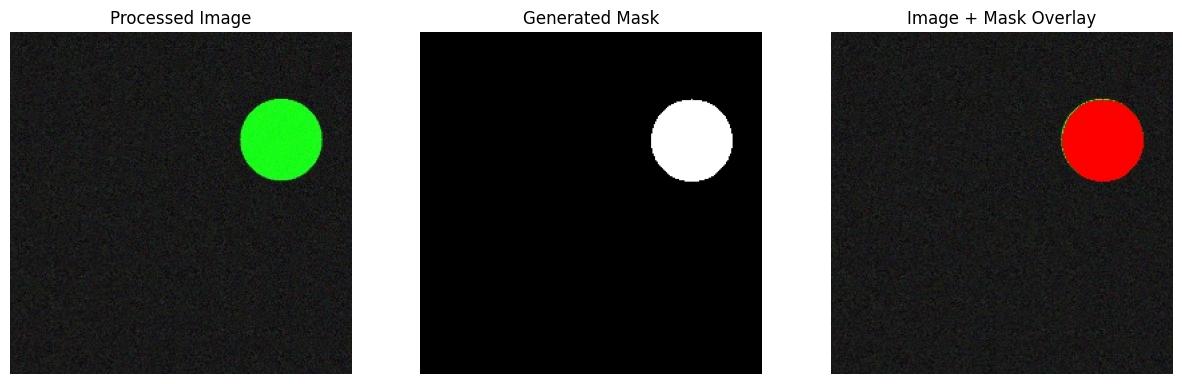

Image shape: (256, 256, 3)
Mask shape: (256, 256)
Mask unique values: [  0 255]


In [ ]:
# Quick verification - shows one  sample
def show_sample(output_dir):
     # Display one processed sample to verify
    import matplotlib.pyplot as plt

    # Find output files
    files = os.listdir(output_dir)
    processed_imgs = [f for f in files if "_processed.jpg" in f]

    if not processed_imgs:
        print("No processed images found!")
        return

    # Load first sample
    sample_name = processed_imgs[0].replace("_processed.jpg", "")

    img_path = os.path.join(output_dir, f"{sample_name}_processed.jpg")
    mask_path = os.path.join(output_dir, f"{sample_name}_mask.png")
    overlay_path = os.path.join(output_dir, f"{sample_name}_overlay.jpg")

    # Read and display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    overlay = cv2.imread(overlay_path)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    axes[0].imshow(img)
    axes[0].set_title("Processed Image")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Generated Mask")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title("Image + Mask Overlay")
    axes[2].axis('off')

    plt.show()

    print(f"Image shape: {img.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"Mask unique values: {np.unique(mask)}")

# Show a sample
show_sample(output_dir)